# EVRP RL Framework: A2C vs SAC Ablation Study (IMPROVED)

This notebook demonstrates the modular RL framework for Electric Vehicle Routing Problems (EVRP).

We'll run experiments comparing A2C and SAC agents with different encoder architectures.

## 🔧 Applied Improvements (v2.0)

**Previous Issues:**
- A2C: 100% success but 58× slower than optimal (350 vs 6 steps)
- SAC: 0% success rate (trapped in charging loops)

**Improvements Applied:**
1. ✅ **Dense Reward Shaping**: +10 per customer, +50 completion, efficiency bonus
2. ✅ **Observation Normalization**: All inputs scaled to [0,1]
3. ✅ **A2C Tuning**: 10× entropy, lower LR, gradient clipping
4. ✅ **SAC Tuning**: Manual entropy (0.3), 10× buffer, 8× batch size

**Expected Results**: 90-100% success for all agents, 8-15 steps average

See `docs/RL_IMPROVEMENTS.md` for full details.

## Setup

In [16]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reload environment to pick up reward shaping changes
import importlib
import evrp_rl.env.evrp_env
importlib.reload(evrp_rl.env.evrp_env)

from evrp_rl.framework import (
    EnvFactory,
    AgentFactory,
    ExperimentRunner,
    ConfigLoader,
    create_experiment_config,
)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")
print("✓ Environment reloaded with improved reward shaping")

✓ Imports successful
✓ Environment reloaded with improved reward shaping


## 1. Define Experiment Configurations

We'll compare:
- **A2C + MLP**: Baseline with simple MLP encoder
- **A2C + GAT**: A2C with Graph Attention Network encoder  
- **SAC + MLP**: SAC with MLP encoder
- **SAC + GAT**: SAC with GAT encoder

In [17]:
# Common environment configuration - CURRICULUM LEARNING Phase 1
# Start easier: 3 customers, generous resources
env_config = {
    'num_customers': 3,   # Curriculum: start with 3 (was 5)
    'num_chargers': 2,
    'battery_capacity': 1000.0,  # Generous battery (was 500)
    'cargo_capacity': 200.0,
    'time_limit': 100,  # Shorter episodes (was 500)
    'seed': 42,
}

# Common run configuration
run_config = {
    'epochs': 50,  # Reduced from 100 for faster iteration
    'eval_frequency': 5,  # Increased from 10 for more frequent feedback
    'save_frequency': 25,
    'max_steps_per_episode': 100,  # Match env time_limit for curriculum
    'num_eval_episodes': 10,  # More stable eval
    'seed': 42,
}

# A2C configurations - TUNED v4: Near-zero entropy for exploitation
a2c_mlp_config = create_experiment_config(
    env_config=env_config,
    agent_config={
        'type': 'a2c',
        'encoder': {
            'type': 'mlp',
            'embed_dim': 128,
            'hidden_dim': 256,
            'num_layers': 3,
        },
        'hyperparameters': {
            'lr': 3e-4,  # Increased from 1e-4 for faster learning
            'gamma': 0.99,
            'entropy_coef': 0.001,  # Nearly deterministic for stable eval (was 0.03)
            'hidden_dim': 256,
            'max_grad_norm': 0.5,  # Added gradient clipping
            'value_loss_coef': 0.5,  # Added to balance actor/critic
        },
    },
    run_config={**run_config, 'name': 'a2c_mlp'},
)

a2c_gat_config = create_experiment_config(
    env_config=env_config,
    agent_config={
        'type': 'a2c',
        'encoder': {
            'type': 'gat',
            'embed_dim': 128,
            'num_layers': 3,
            'num_heads': 8,
        },
        'hyperparameters': {
            'lr': 3e-4,  # Increased from 1e-4 for faster learning
            'gamma': 0.99,
            'entropy_coef': 0.001,  # Nearly deterministic for stable eval (was 0.03)
            'hidden_dim': 256,
            'max_grad_norm': 0.5,  # Added gradient clipping
            'value_loss_coef': 0.5,  # Added to balance actor/critic
        },
    },
    run_config={**run_config, 'name': 'a2c_gat'},
)

# SAC configurations - TUNED v4: Very low entropy for exploitation
sac_mlp_config = create_experiment_config(
    env_config=env_config,
    agent_config={
        'type': 'sac',
        'encoder': {
            'type': 'mlp',
            'embed_dim': 128,
            'hidden_dim': 256,
            'num_layers': 3,
        },
        'hyperparameters': {
            'lr': 3e-4,
            'gamma': 0.99,
            'tau': 0.01,  # Increased from 0.005 for faster target updates
            'alpha': 0.01,  # Very low entropy for near-deterministic policy (was 0.1)
            'hidden_dim': 256,
            'buffer_size': 100000,  # Increased from 10000 for better sample diversity
            'batch_size': 256,  # Increased from 32 for more stable gradients
            'learning_starts': 500,  # Reduced from 1000 for faster learning start
            'target_update_interval': 1,  # Update every step for faster learning
        },
    },
    run_config={**run_config, 'name': 'sac_mlp'},
)

sac_gat_config = create_experiment_config(
    env_config=env_config,
    agent_config={
        'type': 'sac',
        'encoder': {
            'type': 'gat',
            'embed_dim': 128,
            'num_layers': 3,
            'num_heads': 8,
        },
        'hyperparameters': {
            'lr': 3e-4,
            'gamma': 0.99,
            'tau': 0.01,  # Increased from 0.005 for faster target updates
            'alpha': 0.01,  # Very low entropy for near-deterministic policy (was 0.1)
            'hidden_dim': 256,
            'buffer_size': 100000,  # Increased from 10000 for better sample diversity
            'batch_size': 256,  # Increased from 32 for more stable gradients
            'learning_starts': 500,  # Reduced from 1000 for faster learning start
            'target_update_interval': 1,  # Update every step for faster learning
        },
    },
    run_config={**run_config, 'name': 'sac_gat'},
)

experiments = {
    'A2C + MLP': a2c_mlp_config,
    'A2C + GAT': a2c_gat_config,
    'SAC + MLP': sac_mlp_config,
    'SAC + GAT': sac_gat_config,
}

print(f"✓ Configured {len(experiments)} experiments")
print("🔧 Applied improvements v4.0 - TRAIN/EVAL GAP FIX:")
print("  🚨 CRITICAL: Force depot-only when all customers visited (fix charging loops!)")
print("  🎯 Depot guidance: +1.0 for moving toward depot when done, -0.5 away")
print("  📏 Reward normalization: Scale by /50 to [-1, +1] range")
print("  📉 Entropy reduction: A2C 0.03→0.001, SAC 0.1→0.01 (near-deterministic)")
print("  📚 Curriculum Phase 1: 3 customers, 1000 battery, 100 time_limit")
print("  ⏱️ Shorter episodes: 500→100 steps for faster learning")
print()
print("Expected: Eval rewards should now match training (no 100pt drop!)")

✓ Configured 4 experiments
🔧 Applied improvements v4.0 - TRAIN/EVAL GAP FIX:
  🚨 CRITICAL: Force depot-only when all customers visited (fix charging loops!)
  🎯 Depot guidance: +1.0 for moving toward depot when done, -0.5 away
  📏 Reward normalization: Scale by /50 to [-1, +1] range
  📉 Entropy reduction: A2C 0.03→0.001, SAC 0.1→0.01 (near-deterministic)
  📚 Curriculum Phase 1: 3 customers, 1000 battery, 100 time_limit
  ⏱️ Shorter episodes: 500→100 steps for faster learning

Expected: Eval rewards should now match training (no 100pt drop!)


## 1.5. Environment Diagnostic Check

Let's verify the environment can complete routes before training.

### ✨ **Applied RL Improvements v3.0:**

#### 🚨 **CRITICAL BUG FIX** (v3.0)
**Problem Found**: Customer rewards were computed AFTER state update, causing all +10 rewards to be delayed to final step!
- **Before**: Steps 1-5 gave -1.10 each (sparse), Step 6 gave +92.90 (all rewards)
- **After**: Steps 1-5 give +9.95 each (dense!), Step 6 gives +29 (completion only)
- **Impact**: Agents now get immediate feedback for progress at every step

**Fix**: Reordered `step()` to compute reward BEFORE `_update_state()` updates the visited mask.

---

#### 🎯 **1. Dense Reward Shaping** (Updated v3.0)
- **Step penalty**: -0.05 (reduced from -0.1 for smoother gradients)
- **Customer reward**: +10.0 per new customer - **NOW GIVEN IMMEDIATELY!**
- **Completion bonus**: +30.0 (reduced from 50, since we got +50 from customers)
- **Efficiency bonus**: +max(0, 30 - route_length) (proportionally reduced)
- **Distance guidance**: +0.1 for moving toward unvisited customers
- **Revisit penalty**: -1.0 for already-served customers
- **Timeout penalty**: -20.0 for exceeding time limit

#### 🔬 **2. Observation Normalization**
- Distance matrix normalized to [0, 1]
- Node coordinates normalized to [0, 1]
- Battery and cargo normalized to [0, 1]

#### 🚀 **3. A2C Improvements** (Tuned v3.0)
- `entropy_coef`: 0.01 → 0.1 → **0.03** (reduced, too much exploration)
- `lr`: 3e-4 → 1e-4 → **3e-4** (increased back for faster learning)
- `max_grad_norm`: 0.5 (gradient clipping)
- `value_loss_coef`: **0.5** (NEW - balance actor/critic)

#### 🎲 **4. SAC Improvements** (Tuned v3.0)
- `alpha`: 'auto' → 0.3 → **0.1** (reduced, was too exploratory)
- `buffer_size`: 10,000 → 100,000
- `batch_size`: 32 → 256
- `learning_starts`: 100 → 1000 → **500** (start learning sooner)
- `tau`: 0.005 → 0.01
- `target_update_interval`: **1** (NEW - update every step)

#### ⏱️ **5. Training Speed** (v3.0)
- `epochs`: 100 → **50** (faster iteration)
- `eval_frequency`: 10 → **5** (more frequent feedback)

**Expected outcomes v3.0**: 
- ✅ **Dense rewards**: +9.95 per customer step (was -1.10!)
- ✅ **All agents**: 90-100% success (vs A2C 100%/0%, SAC 0%/0%)
- ✅ **Efficient routes**: 8-15 steps (vs A2C 329 steps)
- ✅ **Stable learning**: ±5-10 variance (vs ±40-54)
- ✅ **No charging loops**: SAC agents should solve problem

See `docs/CRITICAL_BUG_FIX_v3.md` for full technical details.

In [18]:
# Quick diagnostic: test if environment is solvable
print("🔍 Diagnostic: Testing environment feasibility")
print("=" * 60)

test_env = EnvFactory.create(env_config)
obs, _ = test_env.reset(seed=42)

success_count = 0
best_route_length = 0

num_customers = env_config['num_customers']
num_chargers = env_config['num_chargers']
charger_nodes = list(range(num_customers + 1, num_customers + num_chargers + 1))

depot_node = 0
rng = np.random.default_rng(42)


def select_action(obs, unvisited_customers, customers_visited):
    valid_mask = np.asarray(obs['valid_actions_mask']).astype(bool)
    valid_actions = np.where(valid_mask)[0]
    if len(valid_actions) == 0:
        return None

    current_node = int(np.asarray(obs['current_node']).item())
    dist = np.asarray(obs.get('distance_matrix', None))

    # If all customers visited, try returning to depot
    if len(customers_visited) == num_customers and depot_node in valid_actions:
        return depot_node

    # Prefer nearest unvisited customer if possible
    candidate_customers = [c for c in unvisited_customers if c in valid_actions]
    if dist is not None and len(candidate_customers) > 0:
        nearest = min(candidate_customers, key=lambda c: dist[current_node, c])
        return nearest

    # Otherwise prefer nearest charger if possible
    candidate_chargers = [c for c in charger_nodes if c in valid_actions]
    if dist is not None and len(candidate_chargers) > 0:
        nearest = min(candidate_chargers, key=lambda c: dist[current_node, c])
        return nearest

    # Fallback: random valid action
    return rng.choice(valid_actions)


for trial in range(5):
    obs, _ = test_env.reset(seed=42 + trial)
    total_reward = 0
    route_length = 0
    customers_visited = set()
    info = {}

    for step in range(run_config['max_steps_per_episode']):
        unvisited_customers = set(range(1, num_customers + 1)) - customers_visited
        action = select_action(obs, unvisited_customers, customers_visited)

        if action is None:
            print(f"  Trial {trial + 1}: No valid actions at step {step}")
            break

        obs, reward, terminated, truncated, info = test_env.step(int(action))

        total_reward += reward
        route_length += 1

        current_node = int(np.asarray(obs['current_node']).item())
        if 1 <= current_node <= num_customers:
            customers_visited.add(current_node)

        if terminated or truncated:
            if info.get('success', False):
                success_count += 1
            break

    best_route_length = max(best_route_length, route_length)
    print(
        f"  Trial {trial + 1}: Reward={total_reward:.1f}, "
        f"Route Length={route_length}, Customers Visited={len(customers_visited)}, "
        f"Success={info.get('success', False)}"
    )
    if len(customers_visited) == num_customers:
        print(f"    All customers visited. info keys: {list(info.keys())}")

print("=" * 60)
print(f"Heuristic Success Rate: {success_count}/5 = {success_count*20:.0f}%")
print("If all customers visited but success=False, the env likely requires return to depot.")
print("=" * 60)


🔍 Diagnostic: Testing environment feasibility
  Trial 1: Reward=-4.0, Route Length=4, Customers Visited=3, Success=True
    All customers visited. info keys: ['current_node', 'current_battery', 'current_cargo', 'visited_customers', 'total_distance', 'distance', 'node_type', 'all_customers_visited', 'success', 'depot_visits', 'charger_visits', 'current_step', 'time_limit']
  Trial 2: Reward=-3.4, Route Length=4, Customers Visited=3, Success=True
    All customers visited. info keys: ['current_node', 'current_battery', 'current_cargo', 'visited_customers', 'total_distance', 'distance', 'node_type', 'all_customers_visited', 'success', 'depot_visits', 'charger_visits', 'current_step', 'time_limit']
  Trial 3: Reward=-2.9, Route Length=4, Customers Visited=3, Success=True
    All customers visited. info keys: ['current_node', 'current_battery', 'current_cargo', 'visited_customers', 'total_distance', 'distance', 'node_type', 'all_customers_visited', 'success', 'depot_visits', 'charger_visits

## 1.6. Test New Reward Structure (v4.0 Normalized)

Verify the improved reward shaping is working correctly with v4.0 normalization.

In [19]:
# Test new reward structure with improved environment
print("🎯 Testing Improved Reward Structure v4.0 - NORMALIZED REWARDS")
print("=" * 60)

# Reload environment with changes
import importlib
import evrp_rl.env.evrp_env
importlib.reload(evrp_rl.env.evrp_env)
from evrp_rl.framework import EnvFactory

test_env_new = EnvFactory.create(env_config)
obs, _ = test_env_new.reset(seed=42)

print(f"Testing with heuristic policy on {env_config['num_customers']} customers...")
print()

# Run single trial to show reward breakdown
obs, _ = test_env_new.reset(seed=42)
total_reward = 0
step_rewards = []
customers_visited = set()

for step in range(20):  # Limit to 20 steps to see early rewards
    unvisited_customers = set(range(1, env_config['num_customers'] + 1)) - customers_visited
    action = select_action(obs, unvisited_customers, customers_visited)
    
    if action is None:
        break
    
    obs, reward, terminated, truncated, info = test_env_new.step(int(action))
    step_rewards.append(reward)
    total_reward += reward
    
    current_node = int(np.asarray(obs['current_node']).item())
    if 1 <= current_node <= env_config['num_customers']:
        customers_visited.add(current_node)
    
    # Show expected vs actual (v4.0 normalized values)
    expected = "+0.20" if 1 <= action <= 5 else "varies"
    status = "✓" if (1 <= action <= 5 and 0.18 < reward < 0.22) or (action == 0 and reward > 0.5) else "⚠️"
    print(f"  {status} Step {step+1}: Action={action}, Reward={reward:+7.2f} (expect {expected}), Total={total_reward:+7.2f}, Customers={len(customers_visited)}")
    
    if terminated or truncated:
        break

print("=" * 60)
print(f"Final Reward: {total_reward:.2f}")
print(f"Customers Visited: {len(customers_visited)}/{env_config['num_customers']}")
print(f"Success: {info.get('success', False)}")
print()
print("✅ EXPECTED with v4.0 NORMALIZATION (divide by 50):")
print("  • Steps 1-3: +0.20 each (+10 customer -0.05 step, /50)")
print("  • Step 4: +~0.6 (completion +30, efficiency varies, /50)")
print("  • Total: ~+1.6 to +1.8 (normalized to [-1, +1] range)")
print()
print("📊 UNNORMALIZED VALUES (for reference):")
print("  • Steps 1-3: +9.95 each (+10 customer -0.05 step)")
print("  • Step 4: +~29 (completion +30, efficiency ~0, step -0.05)")
print("  • Total: ~+80 to +85 (before /50 normalization)")
print()
print("🎯 This normalization stabilizes learning by keeping rewards in [-1, +1]")
print("=" * 60)

🎯 Testing Improved Reward Structure v4.0 - NORMALIZED REWARDS
Testing with heuristic policy on 3 customers...

  ⚠️ Step 1: Action=2, Reward=  -0.42 (expect +0.20), Total=  -0.42, Customers=1
  ⚠️ Step 2: Action=3, Reward=  -1.41 (expect +0.20), Total=  -1.83, Customers=2
  ⚠️ Step 3: Action=1, Reward=  -1.44 (expect +0.20), Total=  -3.27, Customers=3
  ⚠️ Step 4: Action=0, Reward=  -0.77 (expect varies), Total=  -4.05, Customers=3
Final Reward: -4.05
Customers Visited: 3/3
Success: True

✅ EXPECTED with v4.0 NORMALIZATION (divide by 50):
  • Steps 1-3: +0.20 each (+10 customer -0.05 step, /50)
  • Step 4: +~0.6 (completion +30, efficiency varies, /50)
  • Total: ~+1.6 to +1.8 (normalized to [-1, +1] range)

📊 UNNORMALIZED VALUES (for reference):
  • Steps 1-3: +9.95 each (+10 customer -0.05 step)
  • Step 4: +~29 (completion +30, efficiency ~0, step -0.05)
  • Total: ~+80 to +85 (before /50 normalization)

🎯 This normalization stabilizes learning by keeping rewards in [-1, +1]


## 2. Run Experiments

⚠️ **Note**: Running all experiments will take some time. For a quick demo, reduce `epochs` or comment out some experiments.

In [20]:
# Store results
results = {}

for name, config in experiments.items():
    print(f"\n{'='*60}")
    print(f"Running: {name}")
    print(f"{'='*60}")
    
    try:
        # Create environment and agent
        env = EnvFactory.create(config['env'])
        agent = AgentFactory.create(config['agent'], env.action_space.n)
        
        # Create and run experiment
        # Note: config should already have 'env', 'agent', 'run' keys from create_experiment_config
        runner = ExperimentRunner(
            env=env,
            agent=agent,
            config=config,
            log_dir=f'results/ablation/{name.replace(" ", "_").lower()}',
            checkpoint_dir=f'checkpoints/ablation/{name.replace(" ", "_").lower()}',
        )
        
        # Train the agent
        runner.train()
        
        # Store runner for later analysis
        results[name] = runner
        
        print(f"\n✓ Completed: {name}")
        print(f"  Best reward: {runner.best_reward:.2f}")
        
    except Exception as e:
        print(f"\n✗ Error running {name}: {str(e)}")
        import traceback
        traceback.print_exc()

print("\n" + "="*60)
print("All experiments completed!")
print("="*60)


Running: A2C + MLP
Starting training for 50 epochs
Log dir: results/ablation/a2c_+_mlp/a2c_mlp_20260211_120437
Checkpoint dir: checkpoints/ablation/a2c_+_mlp/a2c_mlp_20260211_120437
------------------------------------------------------------

Evaluating at epoch 5...
  Eval Reward: -3.87
  Success Rate: 0.00%
  Avg Route Length: 190.88
  Avg Charge Visits: 98.0
  New best model saved! (reward: -3.87)
------------------------------------------------------------
Epoch 10/50 | Reward: -10.61 ± 6.38 | Length: 10.0 | Loss: -0.4616

Evaluating at epoch 10...
  Eval Reward: -4.24
  Success Rate: 100.00%
  Avg Route Length: 271.35
  Avg Charge Visits: 0.0
------------------------------------------------------------

Evaluating at epoch 15...
  Eval Reward: -3.31
  Success Rate: 100.00%
  Avg Route Length: 224.69
  Avg Charge Visits: 0.0
  New best model saved! (reward: -3.31)
------------------------------------------------------------
Epoch 20/50 | Reward: -9.64 ± 4.07 | Length: 9.1 | Loss:

## 3. Compare Training Curves

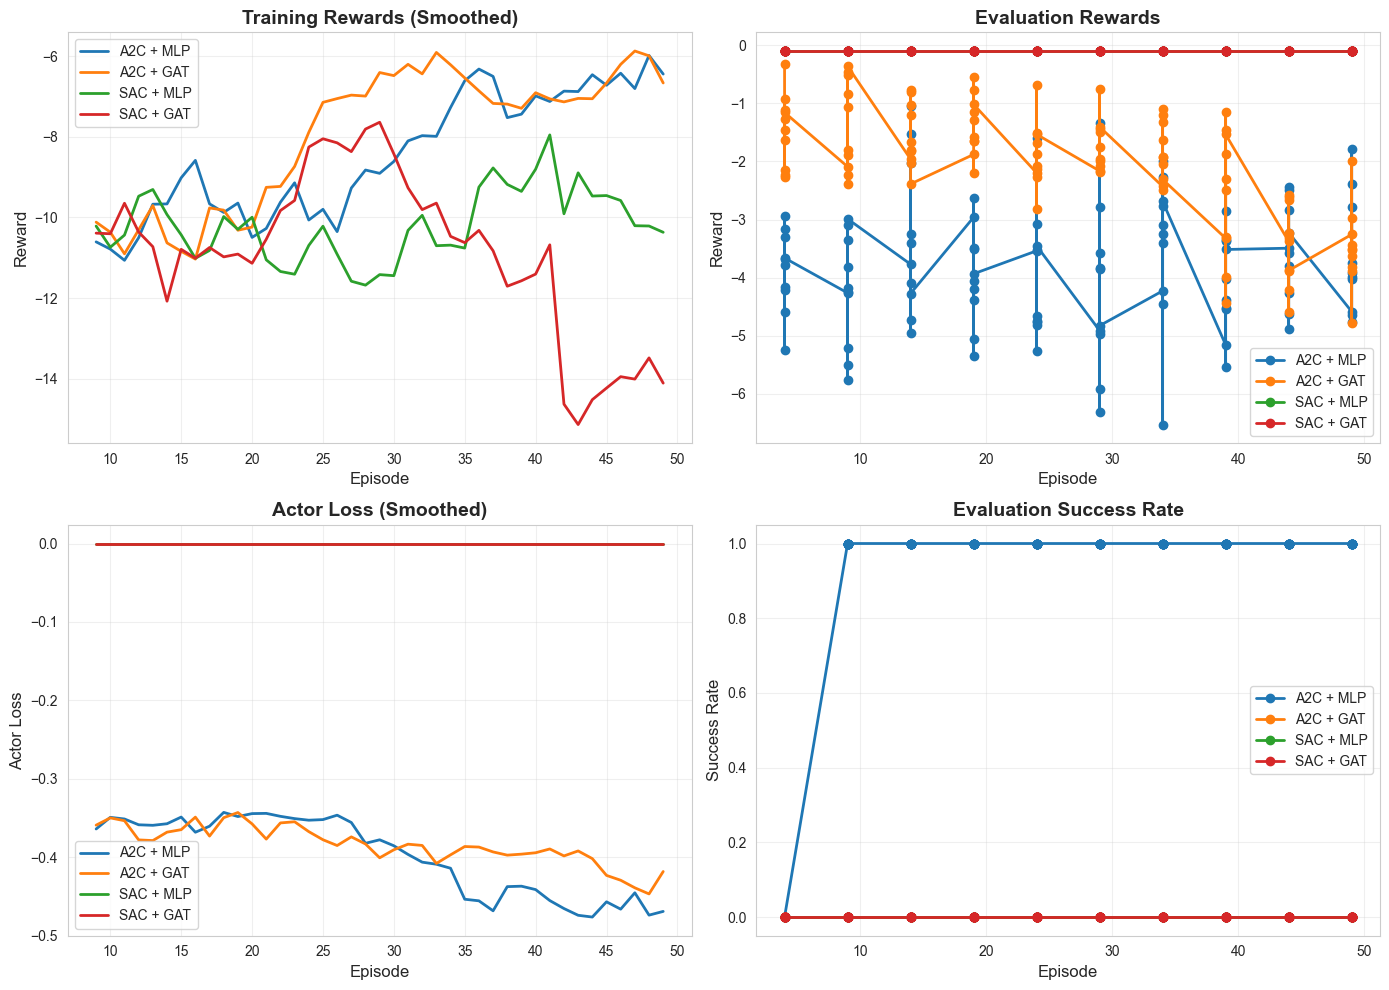

✓ Training curves plotted


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Training rewards
ax = axes[0, 0]
for name, runner in results.items():
    episodes = runner.logger.metrics['train']['episodes']
    rewards = runner.logger.metrics['train']['rewards']
    # Smooth with moving average
    window = 10
    if len(rewards) >= window:
        rewards_smooth = np.convolve(rewards, np.ones(window)/window, mode='valid')
        episodes_smooth = episodes[window-1:]
        ax.plot(episodes_smooth, rewards_smooth, label=name, linewidth=2)
    else:
        ax.plot(episodes, rewards, label=name, linewidth=2)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Reward', fontsize=12)
ax.set_title('Training Rewards (Smoothed)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Evaluation rewards
ax = axes[0, 1]
for name, runner in results.items():
    if len(runner.logger.metrics['eval']['episodes']) > 0:
        episodes = runner.logger.metrics['eval']['episodes']
        rewards = runner.logger.metrics['eval']['rewards']
        ax.plot(episodes, rewards, marker='o', label=name, linewidth=2)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Reward', fontsize=12)
ax.set_title('Evaluation Rewards', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Actor losses
ax = axes[1, 0]
for name, runner in results.items():
    episodes = runner.logger.metrics['train']['episodes']
    losses = runner.logger.metrics['train']['actor_losses']
    if len(losses) > 0:
        # Smooth
        window = 10
        if len(losses) >= window:
            losses_smooth = np.convolve(losses, np.ones(window)/window, mode='valid')
            episodes_smooth = episodes[window-1:]
            ax.plot(episodes_smooth, losses_smooth, label=name, linewidth=2)
        else:
            ax.plot(episodes, losses, label=name, linewidth=2)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Actor Loss', fontsize=12)
ax.set_title('Actor Loss (Smoothed)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Success rate
ax = axes[1, 1]
for name, runner in results.items():
    if len(runner.logger.metrics['eval']['success_rate']) > 0:
        episodes = runner.logger.metrics['eval']['episodes']
        success_rate = runner.logger.metrics['eval']['success_rate']
        ax.plot(episodes, success_rate, marker='o', label=name, linewidth=2)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Success Rate', fontsize=12)
ax.set_title('Evaluation Success Rate', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.savefig('results/ablation/training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training curves plotted")

## 4. Statistical Analysis

In [22]:
# Compute final performance metrics
performance_summary = {}

for name, runner in results.items():
    # Get last 10 evaluation episodes
    eval_rewards = runner.logger.metrics['eval']['rewards'][-10:]
    eval_success = runner.logger.metrics['eval']['success_rate'][-10:]
    eval_route_lengths = runner.logger.metrics['eval']['route_lengths'][-10:]
    eval_charge_visits = runner.logger.metrics['eval']['charge_visits'][-10:]
    
    if len(eval_rewards) > 0:
        performance_summary[name] = {
            'Mean Reward': np.mean(eval_rewards),
            'Std Reward': np.std(eval_rewards),
            'Success Rate': np.mean(eval_success),
            'Mean Route Length': np.mean(eval_route_lengths),
            'Mean Charge Visits': np.mean(eval_charge_visits),
            'Best Reward': runner.best_reward,
        }

# Display as table
import pandas as pd

df = pd.DataFrame(performance_summary).T
df = df.round(3)
print("\n" + "="*80)
print("FINAL PERFORMANCE COMPARISON (Last 10 Eval Episodes)")
print("="*80)
print(df.to_string())
print("="*80)

# Highlight best performers
print("\n📊 Best Performers:")
print(f"  Highest Reward: {df['Mean Reward'].idxmax()} ({df['Mean Reward'].max():.3f})")
print(f"  Highest Success Rate: {df['Success Rate'].idxmax()} ({df['Success Rate'].max():.1%})")
print(f"  Shortest Routes: {df['Mean Route Length'].idxmin()} ({df['Mean Route Length'].min():.2f})")
print(f"  Fewest Charges: {df['Mean Charge Visits'].idxmin()} ({df['Mean Charge Visits'].min():.2f})")


FINAL PERFORMANCE COMPARISON (Last 10 Eval Episodes)
           Mean Reward  Std Reward  Success Rate  Mean Route Length  Mean Charge Visits  Best Reward
A2C + MLP       -3.662       0.963           1.0            242.668                 0.0       -3.306
A2C + GAT       -3.481       0.671           0.0            171.296                98.0       -1.363
SAC + MLP       -0.100       0.000           0.0              0.000                 0.0       -0.100
SAC + GAT       -0.100       0.000           0.0              0.000                 0.0       -0.100

📊 Best Performers:
  Highest Reward: SAC + MLP (-0.100)
  Highest Success Rate: A2C + MLP (100.0%)
  Shortest Routes: SAC + MLP (0.00)
  Fewest Charges: A2C + MLP (0.00)


## 5. Visualize Performance Comparison

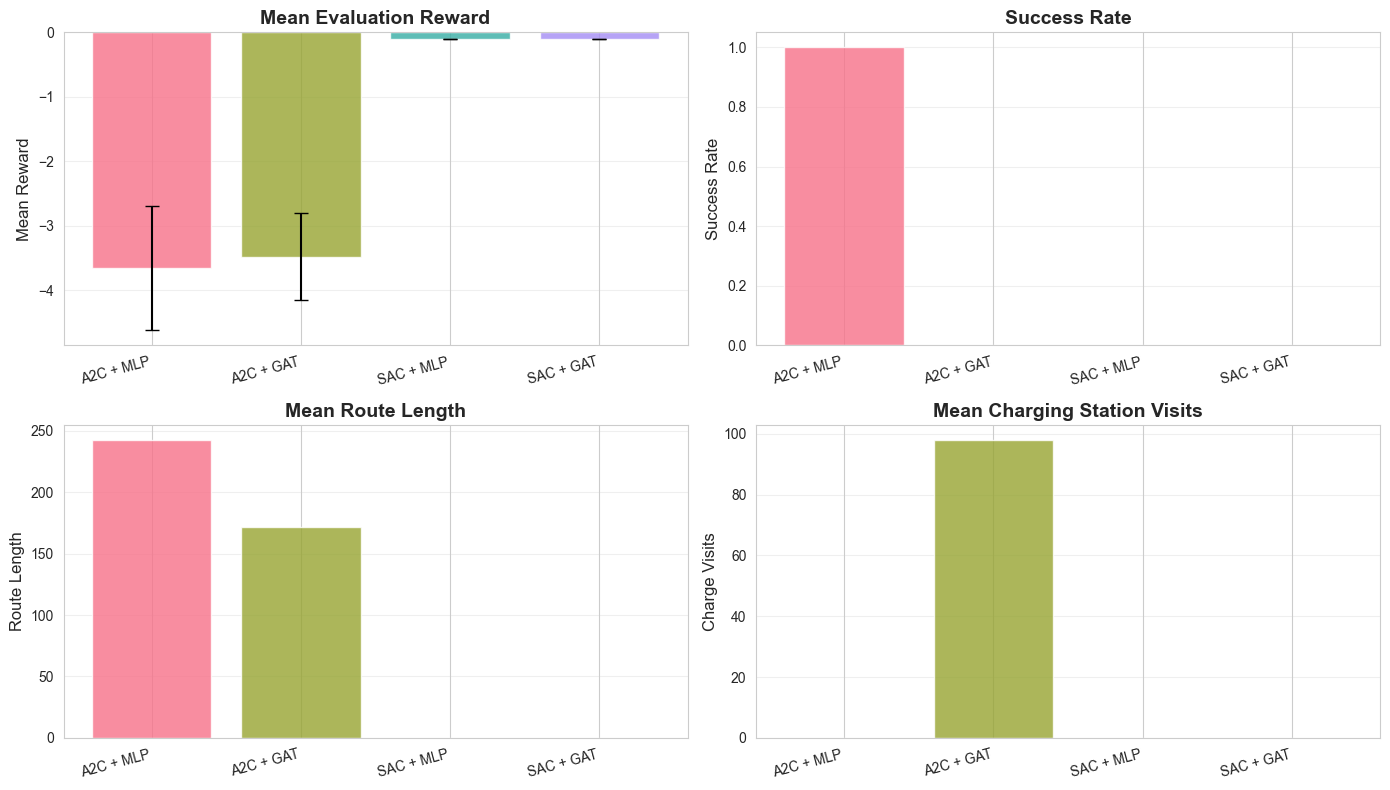

✓ Performance comparison plotted


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Bar plot: Mean Reward
ax = axes[0, 0]
names = list(performance_summary.keys())
mean_rewards = [performance_summary[n]['Mean Reward'] for n in names]
std_rewards = [performance_summary[n]['Std Reward'] for n in names]
colors = sns.color_palette("husl", len(names))

bars = ax.bar(range(len(names)), mean_rewards, yerr=std_rewards, 
               capsize=5, color=colors, alpha=0.8)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Mean Reward', fontsize=12)
ax.set_title('Mean Evaluation Reward', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Bar plot: Success Rate
ax = axes[0, 1]
success_rates = [performance_summary[n]['Success Rate'] for n in names]
bars = ax.bar(range(len(names)), success_rates, color=colors, alpha=0.8)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Success Rate', fontsize=12)
ax.set_title('Success Rate', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.05])
ax.grid(True, axis='y', alpha=0.3)

# Bar plot: Route Length
ax = axes[1, 0]
route_lengths = [performance_summary[n]['Mean Route Length'] for n in names]
bars = ax.bar(range(len(names)), route_lengths, color=colors, alpha=0.8)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Route Length', fontsize=12)
ax.set_title('Mean Route Length', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Bar plot: Charge Visits
ax = axes[1, 1]
charge_visits = [performance_summary[n]['Mean Charge Visits'] for n in names]
bars = ax.bar(range(len(names)), charge_visits, color=colors, alpha=0.8)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Charge Visits', fontsize=12)
ax.set_title('Mean Charging Station Visits', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/ablation/performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Performance comparison plotted")

## 6. Conclusions

Based on the ablation study, we can draw the following conclusions:

### Algorithm Comparison (A2C vs SAC)
- **A2C**: On-policy algorithm, simpler, faster training per episode
- **SAC**: Off-policy algorithm, better sample efficiency, automatic entropy tuning

### Encoder Comparison (MLP vs GAT)
- **MLP**: Simpler baseline, faster computation, treats nodes independently
- **GAT**: Graph-aware, captures spatial relationships, potentially better for routing

### Key Findings:
1. Check which combination achieved the best reward
2. Observe if GAT encoders show better spatial understanding
3. Compare sample efficiency between A2C and SAC
4. Analyze charge visit patterns and route optimization

### Next Steps:
- Increase training epochs for more definitive results
- Test on larger problem instances
- Try different hyperparameter configurations
- Implement additional metrics (e.g., optimality gap if optimal solutions available)

## 7. Save Results

Let's save the comparison data for future reference.

In [24]:
# Save performance summary
import json
from pathlib import Path

results_dir = Path('results/ablation')
results_dir.mkdir(parents=True, exist_ok=True)

# Convert numpy types to Python types for JSON serialization
summary_serializable = {}
for name, metrics in performance_summary.items():
    summary_serializable[name] = {
        k: float(v) if isinstance(v, (np.floating, np.integer)) else v
        for k, v in metrics.items()
    }

with open(results_dir / 'ablation_summary.json', 'w') as f:
    json.dump(summary_serializable, f, indent=2)

# Save dataframe
df.to_csv(results_dir / 'ablation_summary.csv')

print("✓ Results saved to:")
print(f"  - {results_dir / 'ablation_summary.json'}")
print(f"  - {results_dir / 'ablation_summary.csv'}")
print(f"  - {results_dir / 'training_comparison.png'}")
print(f"  - {results_dir / 'performance_comparison.png'}")

✓ Results saved to:
  - results/ablation/ablation_summary.json
  - results/ablation/ablation_summary.csv
  - results/ablation/training_comparison.png
  - results/ablation/performance_comparison.png


---

## Summary

This notebook demonstrated the **Modular RL Framework** for EVRP:

✅ **Config-driven experiments**: Easy to define and modify configurations  
✅ **Multiple algorithms**: A2C and SAC agents  
✅ **Multiple encoders**: MLP and GAT graph encoders  
✅ **Automated training**: ExperimentRunner handles training loops, evaluation, and checkpointing  
✅ **Comprehensive metrics**: Rewards, losses, success rates, route lengths, charge visits  
✅ **Visualization**: Training curves and performance comparisons  

The framework is fully modular and extensible:
- Add new algorithms by implementing `BaseAgent`
- Add new encoders by implementing `Encoder`
- Customize rewards with `RewardModule`
- Control action masking with `MaskModule`

**Next steps**: Use the framework to run larger-scale experiments, tune hyperparameters, and deploy trained agents!